In [11]:
!pip install flashtext

  Preparing metadata (setup.py) ... done
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9298 sha256=ec20e2e12630adb90b8a66bead9c9436aa57f39bcbe586ca880d1f6d0336e0ce
  Stored in directory: /root/.cache/pip/wheels/bc/be/39/c37ad168eb2ff644c9685f52554440372129450f0b8ed203dd
Successfully built flashtext


In [28]:
# prompt: read a txt file line by line into a pandas dataframe

import pandas as pd

def read_txt_to_dataframe(filepath):
  """Reads a text file line by line into a pandas DataFrame.

  Args:
    filepath: The path to the text file.

  Returns:
    A pandas DataFrame with one column named 'text' containing each line
    of the file as a separate row. Returns None if an error occurs.
  """
  try:
    with open(filepath, 'r', encoding='utf-8') as file: # Specify UTF-8 encoding
      lines = file.readlines()
      df = pd.DataFrame({'text': lines})
      return df
  except FileNotFoundError:
      print(f"Error: File not found at '{filepath}'")
      return None
  except Exception as e:
      print(f"An error occurred: {e}")
      return None


df = read_txt_to_dataframe('/content/biblia-em-txt.txt')
df

,text
0,BÍBLIA SAGRADA\n
1,Tradução: João Ferreira de Almeida\n
2,Edição Revista e Corrigida\n
3,\t\n
4,ANTIGO TESTAMENTO\n
...,...
32364,21 A graça do Senhor Jesus seja com todos.\n
32365,\n
32366,###########################################\n
32367,## Baixado do site: www.umsocorpo.com.br ##\n


In [29]:
# prompt: how to remove punctuation from a string column in a dataframe

import string

def remove_punctuation(text):
  if isinstance(text, str):
    return text.translate(str.maketrans('', '', string.punctuation))
  else:
    return text

df['Texto_tratado'] = df['text'].apply(remove_punctuation)
df

,text,Texto_tratado
0,BÍBLIA SAGRADA\n,BÍBLIA SAGRADA\n
1,Tradução: João Ferreira de Almeida\n,Tradução João Ferreira de Almeida\n
2,Edição Revista e Corrigida\n,Edição Revista e Corrigida\n
3,\t\n,\t\n
4,ANTIGO TESTAMENTO\n,ANTIGO TESTAMENTO\n
...,...,...
32364,21 A graça do Senhor Jesus seja com todos.\n,21 A graça do Senhor Jesus seja com todos\n
32365,\n,\n
32366,###########################################\n,\n
32367,## Baixado do site: www.umsocorpo.com.br ##\n,Baixado do site wwwumsocorpocombr \n


In [33]:
from flashtext import KeywordProcessor
import nltk

kp = KeywordProcessor()
stopwords_ninjas = ['of', 'a', 'the', '.', '\n', '\t']
nltk.download('stopwords')
stopwords_nltk = list(stopwords.words('portuguese'))
stopwords_ninjas.extend(stopwords_nltk)
for i in stopwords_ninjas:
    kp.add_keyword(i, ' ')

df['Texto_pronto'] = df.Texto_tratado.apply(kp.replace_keywords)
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,Texto_tratado,Texto_pronto
0,BÍBLIA SAGRADA\n,BÍBLIA SAGRADA\n,BÍBLIA SAGRADA\n
1,Tradução: João Ferreira de Almeida\n,Tradução João Ferreira de Almeida\n,Traduçã Joã Ferreira Almeida\n
2,Edição Revista e Corrigida\n,Edição Revista e Corrigida\n,Ediçã Revista Corrigida\n
3,\t\n,\t\n,\n
4,ANTIGO TESTAMENTO\n,ANTIGO TESTAMENTO\n,ANTIGO TESTAMENTO\n
...,...,...,...
32364,21 A graça do Senhor Jesus seja com todos.\n,21 A graça do Senhor Jesus seja com todos\n,21 graç Senhor Jesus todos\n
32365,\n,\n,
32366,###########################################\n,\n,
32367,## Baixado do site: www.umsocorpo.com.br ##\n,Baixado do site wwwumsocorpocombr \n,Baixado site wwwumsocorpocombr


In [38]:
# prompt: how to generate a bag of words, word and count, from a column from a dataframe with strings

from collections import Counter

def generate_bag_of_words(dataframe, column_name):
    """
    Generates a bag of words from a specified column in a Pandas DataFrame.

    Args:
        dataframe: The input Pandas DataFrame.
        column_name: The name of the column containing the strings.

    Returns:
        A dictionary where keys are words and values are their counts.
    """

    bag_of_words = Counter()
    for text in dataframe[column_name]:
      if isinstance(text, str):  # Check if the value is a string
          bag_of_words.update(text.lower().split())
    return bag_of_words

# Example usage:
bag_of_words_result = generate_bag_of_words(df, 'Texto_pronto')
print(bag_of_words_result.most_common(50))


[('senhor', 8016), ('deus', 4417), ('pois', 3382), ('terra', 2936), ('filhos', 2781), ('porque', 2774), ('sobre', 2761), ('entã', 2547), ('israel', 2542), ('rei', 2475), ('todos', 2353), ('filho', 2322), ('disse', 2079), ('assim', 2066), ('casa', 1968), ('mã', 1932), ('povo', 1820), ('contra', 1676), ('vós', 1672), ('homem', 1608), ('dia', 1491), ('todo', 1485), ('mim', 1351), ('homens', 1313), ('1', 1254), ('ti', 1251), ('2', 1250), ('3', 1248), ('4', 1237), ('5', 1227), ('6', 1215), ('7', 1201), ('8', 1188), ('eis', 1185), ('9', 1171), ('10', 1154), ('11', 1132), ('pai', 1123), ('toda', 1120), ('12', 1107), ('dizendo', 1090), ('13', 1080), ('jesus', 1079), ('diz', 1075), ('ém', 1064), ('irmã', 1054), ('14', 1039), ('davi', 1031), ('15', 1005), ('diante', 1003)]


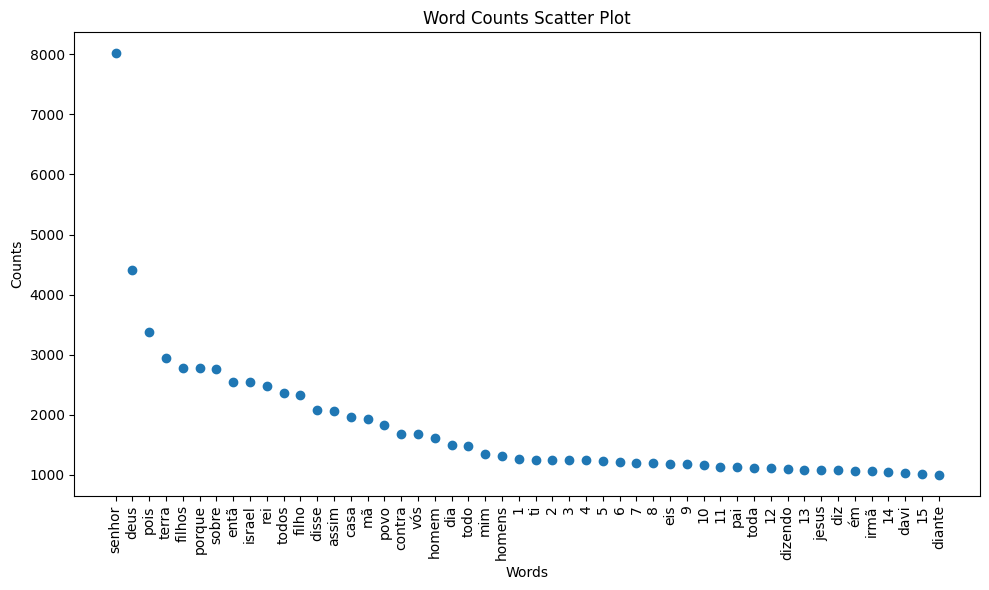

In [39]:
# prompt: make a scatter plot from a counter

import matplotlib.pyplot as plt

# Assuming 'bag_of_words_result' is your Counter object
# Convert the Counter to a list of (word, count) tuples
word_counts = list(bag_of_words_result.most_common(50))

# Extract words and counts into separate lists
words, counts = zip(*word_counts)

# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.scatter(words, counts)
plt.xlabel("Words")
plt.ylabel("Counts")
plt.title("Word Counts Scatter Plot")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()